# RQ2 — What is the impact of UNGA week?

> *"What is the impact of UNGA? Is it in fact the slowest week of the year, and
> if not what is?"*

The question has three parts, and they get different answers:

1. Does UNGA week slow midtown down? **Yes, substantially.**
2. Is it the slowest week of the year? **No.**
3. Then what is? **December.**

### Why this is closer to causal than a normal observational finding

The 75th session (2020) ran on pre-recorded video with almost no delegations in
New York, and the 76th (2021) was hybrid with reduced attendance. That gives us
UNGA *on the calendar* with the motorcades removed — a control condition we did
not have to construct.

### Method

Weekdays, distance-weighted, outage days dropped. UNGA week is the Monday–Sunday
week containing the General Debate opening Tuesday (`constants.unga_week`),
which sidesteps the ambiguity in when the debate formally ends.

Two cuts are reported throughout. **Full weekdays** is the headline. **Mon–Wed**
exists because the September 2023 outage destroyed Thursday and Friday of that
year's UNGA week — restricting to Mon–Wed recovers 2023 and, as it turns out,
isolates the heaviest days of the General Debate.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

import analysis as an
import events
import panel as pnl
from constants import UNGA_GENERAL_DEBATE, UNGA_VIRTUAL_YEARS, UN_ZONES, unga_week

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

panel = pnl.drop_outages(pnl.load_panel())
panel["date"] = pd.to_datetime(panel["date"])

for y in sorted(UNGA_GENERAL_DEBATE):
    a, b = unga_week(y)
    tag = "  <- virtual/hybrid" if y in UNGA_VIRTUAL_YEARS else ""
    print(f"{y}: debate {UNGA_GENERAL_DEBATE[y][0]}..{UNGA_GENERAL_DEBATE[y][1]}   week {a}..{b}{tag}")

2019: debate 2019-09-24..2019-09-30   week 2019-09-23..2019-09-29
2020: debate 2020-09-22..2020-09-29   week 2020-09-21..2020-09-27  <- virtual/hybrid
2021: debate 2021-09-21..2021-09-27   week 2021-09-20..2021-09-26  <- virtual/hybrid
2022: debate 2022-09-20..2022-09-26   week 2022-09-19..2022-09-25
2023: debate 2023-09-19..2023-09-26   week 2023-09-18..2023-09-24
2024: debate 2024-09-24..2024-09-30   week 2024-09-23..2024-09-29
2025: debate 2025-09-23..2025-09-29   week 2025-09-22..2025-09-28
2026: debate 2026-09-22..2026-09-28   week 2026-09-21..2026-09-27


## 1. Where does UNGA week rank within its own year?

Ranked slowest-first, so rank 1 is the slowest week of that year.

In [2]:
full = an.unga_ranking(panel)
monwed = an.unga_ranking(panel, dows=(0, 1, 2), min_days=3)

combined = pd.concat({"full weekdays": full, "Mon–Wed": monwed}, axis=1)
combined.round(2)

full weekdays                                          Mon–Wed                                        
          iso_week   mph  rank weeks median   gap    trips iso_week   mph  rank weeks median   gap    trips
year                                                                                                       
2019            39  4.63   1.0    52   5.77 -1.14  33954.0       39  4.24   1.0    51   5.91 -1.67  18167.0
2020            39  9.51  28.0    53   9.50  0.01   6144.0       39  9.73  28.0    53   9.68  0.05   3575.0
2021            38  6.40   5.0    52   8.08 -1.68  14548.0       38  6.43   5.0    52   8.42 -1.99   8891.0
2022            38  4.77   5.0    52   6.43 -1.65  13557.0       38  4.40   2.0    52   6.42 -2.02   7960.0
2023            38   NaN   NaN    51   5.47   NaN      NaN       38  4.15   1.0    52   5.40 -1.24   9313.0
2024            39  4.22   5.0    52   5.11 -0.89  18354.0       39  4.06   4.0    52   5.13 -1.07  10063.0
2025            39  3.78   3.0    52   5.01 -1.22  17605.0       39  3.68   1.0    52   5.01 -1.32   9157.0
2026            39   NaN   NaN    31   4.75   NaN      NaN       39   NaN   NaN    31   4.61   NaN      NaN

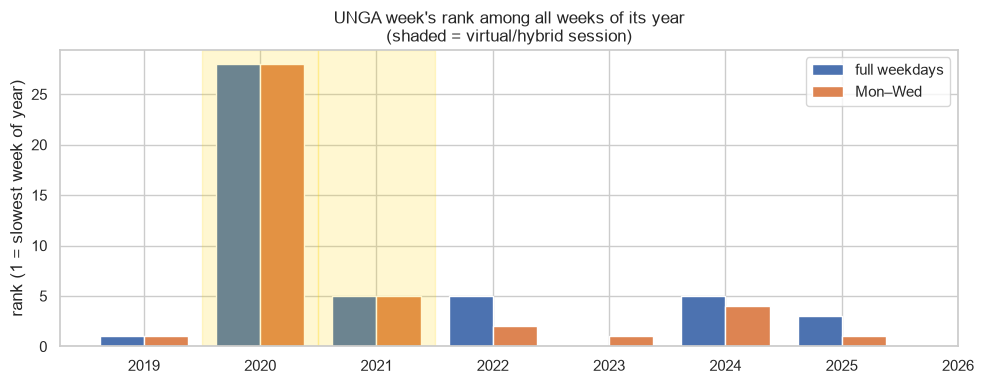

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.38
idx = np.arange(len(full))
ax.bar(idx - w/2, full["rank"], w, label="full weekdays")
ax.bar(idx + w/2, monwed["rank"], w, label="Mon–Wed")
for i, y in enumerate(full.index):
    if y in UNGA_VIRTUAL_YEARS:
        ax.axvspan(i - 0.5, i + 0.5, color="gold", alpha=0.18)
ax.set(xticks=idx, xticklabels=full.index, ylabel="rank (1 = slowest week of year)",
       title="UNGA week's rank among all weeks of its year\n(shaded = virtual/hybrid session)")
ax.legend()
plt.tight_layout(); plt.show()

**The 2020 result is the one to look at.** In every ordinary year UNGA week
lands in the slowest handful. In 2020 — video debate, no delegations — it sits
mid-table. UNGA was on the calendar; the traffic effect was not.

## 2. Against the weeks either side, in the same year

Ranking against a whole year lets the seasonal trend contribute. Comparing UNGA
week only to the three weeks before and after removes that.

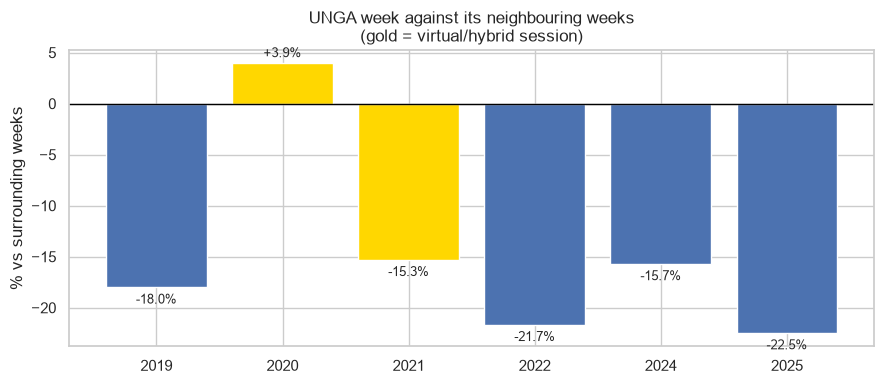

,unga_mph,neighbour_mph,gap,pct,n_neighbours,virtual
year,,,,,,
2019,4.63,5.65,-1.02,-18.00,6,False
2020,9.51,9.15,0.36,3.95,6,True
2021,6.40,7.56,-1.16,-15.30,6,True
2022,4.77,6.09,-1.32,-21.67,6,False
2024,4.22,5.01,-0.79,-15.71,6,False
2025,3.78,4.88,-1.10,-22.48,6,False


In [4]:
nb = an.unga_vs_neighbours(panel)
nb["virtual"] = [y in UNGA_VIRTUAL_YEARS for y in nb.index]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["gold" if v else "#4C72B0" for v in nb.virtual]
bars = ax.bar(nb.index.astype(str), nb.pct, color=colors)
ax.axhline(0, color="black", lw=1)
for b, v in zip(bars, nb.pct):
    ax.text(b.get_x()+b.get_width()/2, v + (0.6 if v > 0 else -1.6), f"{v:+.1f}%",
            ha="center", fontsize=9)
ax.set(ylabel="% vs surrounding weeks", title="UNGA week against its neighbouring weeks\n(gold = virtual/hybrid session)")
plt.tight_layout(); plt.show()

nb.round(2)

## 3. Is it the slowest week of the year? No — December is

The six slowest weeks of each year, with UNGA marked.

In [5]:
rows = []
for y in [2019, 2021, 2022, 2023, 2024, 2025]:
    uw = pd.Timestamp(unga_week(y)[0]).isocalendar().week
    s = an.slowest_weeks(panel, y, n=6).copy()
    s["year"] = y
    s["is_unga"] = s.iso_week == uw
    s["month"] = pd.to_datetime(s.starts).dt.strftime("%b")
    rows.append(s)

slowest = pd.concat(rows)
for y, g in slowest.groupby("year"):
    print(f"\n=== {y} ===")
    print(g[["iso_week", "starts", "month", "mph", "is_unga"]].round(2).to_string(index=False))


=== 2019 ===
 iso_week     starts month  mph  is_unga
       39 2019-09-23   Sep 4.63     True
       50 2019-12-09   Dec 4.67    False
       49 2019-12-02   Dec 4.86    False
       51 2019-12-16   Dec 5.02    False
       46 2019-11-11   Nov 5.15    False
       25 2019-06-17   Jun 5.19    False

=== 2021 ===
 iso_week     starts month  mph  is_unga
       49 2021-12-06   Dec 5.46    False
       48 2021-11-29   Nov 5.80    False
       50 2021-12-13   Dec 5.89    False
       45 2021-11-08   Nov 6.05    False
       38 2021-09-20   Sep 6.40     True
       44 2021-11-01   Nov 6.51    False

=== 2022 ===
 iso_week     starts month  mph  is_unga
       52 2022-12-26   Dec 4.40    False
       49 2022-12-05   Dec 4.45    False
       50 2022-12-12   Dec 4.57    False
       48 2022-11-28   Nov 4.75    False
       38 2022-09-19   Sep 4.77     True
       51 2022-12-19   Dec 4.93    False

=== 2023 ===
 iso_week     starts month  mph  is_unga
       49 2023-12-04   Dec 4.15    False
 

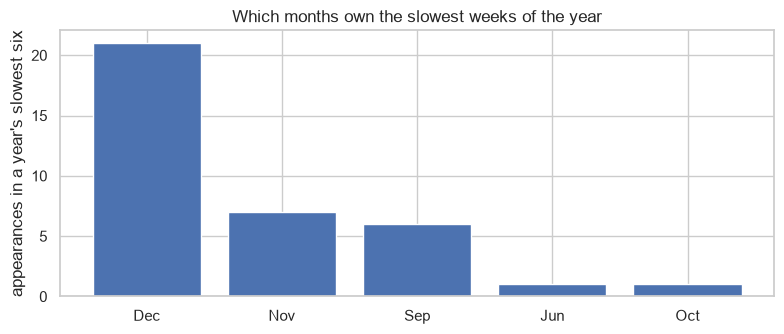

month
Dec    21
Nov     7
Sep     6
Jun     1
Oct     1
Name: count, dtype: int64

In [6]:
# How often does each month supply a "slowest six" week?
share = slowest.month.value_counts()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(share.index, share.values, color="#4C72B0")
ax.set(ylabel="appearances in a year's slowest six",
       title="Which months own the slowest weeks of the year")
plt.tight_layout(); plt.show()
share

## 4. So where does UNGA rank once December is set aside?

December is a five-week shopping and tourism season. UNGA is one week. The fair
comparison is UNGA against the rest of the non-holiday year.

In [7]:
wk = an.week_table(panel)
rows = []
for y in [2019, 2021, 2022, 2024, 2025]:
    uw = pd.Timestamp(unga_week(y)[0]).isocalendar().week
    yr = wk[(wk.iso_year == y) & (~wk.iso_week.between(48, 52))]
    m = yr[yr.iso_week == uw]
    if m.empty:
        continue
    mph = m.mph.iloc[0]
    rows.append({"year": y, "mph": round(mph, 2),
                 "rank_ex_december": int((yr.mph < mph).sum() + 1), "of": len(yr)})

# 2023 via the Mon-Wed cut, since its Thu/Fri are lost to the outage.
wk3 = an.week_table(panel, dows=(0, 1, 2), min_days=3)
yr = wk3[(wk3.iso_year == 2023) & (~wk3.iso_week.between(48, 52))]
mph = yr[yr.iso_week == 38].mph.iloc[0]
rows.append({"year": 2023, "mph": round(mph, 2),
             "rank_ex_december": int((yr.mph < mph).sum() + 1), "of": len(yr), })

pd.DataFrame(rows).sort_values("year").set_index("year")

,mph,rank_ex_december,of
year,,,
2019,4.63,1,47
2021,6.40,2,47
2022,4.77,1,47
2023,4.15,1,47
2024,4.22,1,47
2025,3.78,1,47


## 5. Is the effect local to the UN, or midtown-wide?

If it were only motorcade routes and the security perimeter, the UN-adjacent
zones would carry it and the rest of midtown would barely notice.

UNGA week vs neighbouring weeks, % by area:
area  un_core  midtown_core  midtown_ext   cbd  uptown
year                                                  
2019    -32.0         -18.0        -18.1  -7.5    -3.8
2020      1.3           3.9          2.4   0.6     0.8
2021    -21.6         -15.3        -13.4  -7.9     0.6
2022    -33.3         -21.7        -19.7 -10.1    -5.6
2024    -28.9         -15.7        -15.8  -8.2    -6.5
2025    -26.2         -22.5        -18.9  -5.2     2.8


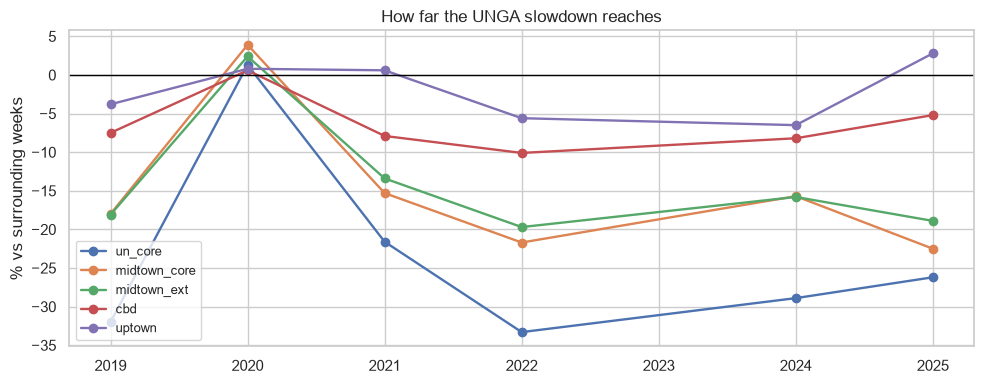

In [8]:
areas = ["un_core", "midtown_core", "midtown_ext", "cbd", "uptown"]
rows = []
for area in areas:
    if area not in set(panel.area):
        print(f"  (skipping {area} - not in panel)")
        continue
    r = an.unga_vs_neighbours(panel, area=area)
    r["area"] = area
    rows.append(r.reset_index())

local = pd.concat(rows)
piv = local.pivot(index="year", columns="area", values="pct").round(1)
piv = piv[[c for c in areas if c in piv.columns]]
print("UNGA week vs neighbouring weeks, % by area:")
print(piv.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for area in piv.columns:
    ax.plot(piv.index, piv[area], marker="o", lw=1.7, label=area)
ax.axhline(0, color="black", lw=1)
ax.set(ylabel="% vs surrounding weeks", title="How far the UNGA slowdown reaches")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Day by day through UNGA week

Which days actually carry it — and does the pattern match a General Debate that
opens on Tuesday?

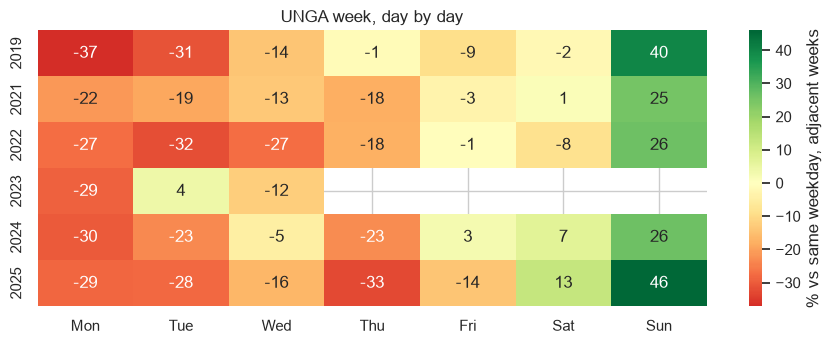

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
year,,,,,,,
2019,-37.2,-31.1,-14.1,-1.2,-8.9,-2.0,39.8
2021,-21.5,-19.1,-13.4,-18.1,-3.1,1.3,25.2
2022,-27.4,-31.7,-27.3,-17.9,-0.6,-8.3,26.4
2023,-29.3,4.2,-12.4,NaN,NaN,NaN,NaN
2024,-30.1,-23.3,-4.9,-23.1,2.6,6.9,26.2
2025,-28.5,-28.1,-16.4,-32.8,-14.3,12.8,46.0


In [9]:
rows = []
for y in [2019, 2021, 2022, 2023, 2024, 2025]:
    mon, sun = unga_week(y)
    base = an.daily(panel, area="midtown_core")
    base = base[(base.date >= pd.Timestamp(mon) - pd.Timedelta(days=7)) &
                (base.date <= pd.Timestamp(sun) + pd.Timedelta(days=7))]
    ref = base[(base.date < pd.Timestamp(mon)) | (base.date > pd.Timestamp(sun))]
    ref_by_dow = ref.groupby(ref.date.dt.dayofweek).apply(
        lambda g: g.miles.sum()/(g.minutes.sum()/60), include_groups=False)
    wk_days = base[(base.date >= pd.Timestamp(mon)) & (base.date <= pd.Timestamp(sun))].copy()
    wk_days["dow"] = wk_days.date.dt.dayofweek
    wk_days["ref"] = wk_days.dow.map(ref_by_dow)
    wk_days["pct"] = (wk_days.mph/wk_days.ref - 1)*100
    wk_days["year"] = y
    rows.append(wk_days[["year", "date", "dow", "mph", "ref", "pct", "trips"]])

daywise = pd.concat(rows)
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
grid = daywise.pivot_table(index="year", columns="dow", values="pct")
grid.columns = [DOW[c] for c in grid.columns]

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(grid, annot=True, fmt=".0f", center=0, cmap="RdYlGn",
            cbar_kws={"label": "% vs same weekday, adjacent weeks"}, ax=ax)
ax.set(title="UNGA week, day by day", ylabel="")
plt.tight_layout(); plt.show()

grid.round(1)

## 7. Do weather or permitted closures explain it?

Two alternative explanations worth eliminating: UNGA weeks happening to be wet,
and the permit feed simply counting UNGA itself.

In [10]:
rows = []
for y in [2019, 2021, 2022, 2023, 2024, 2025]:
    mon, sun = unga_week(y)
    core = panel[panel.area == "midtown_core"]
    inw = core[(core.date >= pd.Timestamp(mon)) & (core.date <= pd.Timestamp(sun))]
    near = core[(core.date.between(pd.Timestamp(mon) - pd.Timedelta(days=21), pd.Timestamp(mon) - pd.Timedelta(days=1))) |
                (core.date.between(pd.Timestamp(sun) + pd.Timedelta(days=1), pd.Timestamp(sun) + pd.Timedelta(days=21)))]
    rows.append({"year": y,
                 "unga_wet_share": inw.is_wet.fillna(False).mean(),
                 "neighbour_wet_share": near.is_wet.fillna(False).mean(),
                 "unga_dry_mph": an.wmph(inw[~inw.is_wet.fillna(False)]),
                 "neighbour_dry_mph": an.wmph(near[~near.is_wet.fillna(False)])})

wx = pd.DataFrame(rows).set_index("year")
wx["dry_only_pct"] = (wx.unga_dry_mph/wx.neighbour_dry_mph - 1)*100
print("Restricting to DRY hours only — does the effect survive?")
print(wx.round(3).to_string())

Restricting to DRY hours only — does the effect survive?
      unga_wet_share  neighbour_wet_share  unga_dry_mph  neighbour_dry_mph  dry_only_pct
year                                                                                    
2019           0.042                0.167         5.123              5.918       -13.431
2021           0.232                0.141         6.944              7.576        -8.339
2022           0.071                0.180         5.269              6.212       -15.175
2023           0.197                0.183         4.242              5.193       -18.302
2024           0.262                0.028         4.497              5.033       -10.657
2025           0.196                0.108         4.455              5.056       -11.877


In [11]:
ev = events.load()
clo = events.daily_midtown_closures(ev)
clo["date"] = pd.to_datetime(clo.date)

rows = []
for y in [2019, 2021, 2022, 2023, 2024, 2025]:
    mon, sun = unga_week(y)
    inw = clo[(clo.date >= pd.Timestamp(mon)) & (clo.date <= pd.Timestamp(sun))]
    near = clo[(clo.date.between(pd.Timestamp(mon)-pd.Timedelta(days=21), pd.Timestamp(mon)-pd.Timedelta(days=1))) |
               (clo.date.between(pd.Timestamp(sun)+pd.Timedelta(days=1), pd.Timestamp(sun)+pd.Timedelta(days=21)))]
    rows.append({"year": y, "unga_road_events": inw.road_events.mean(),
                 "neighbour_road_events": near.road_events.mean()})

perm = pd.DataFrame(rows).set_index("year")
perm["ratio"] = (perm.unga_road_events/perm.neighbour_road_events).round(2)
print("Permitted road-affecting events per day:")
print(perm.round(2).to_string())
print("\nNote: the permit feed captures *permitted* events, not NYPD security")
print("closures, so this understates UNGA-week road loss by design.")

Permitted road-affecting events per day:
      unga_road_events  neighbour_road_events  ratio
year                                                
2019              4.57                   5.24   0.87
2021              3.71                   3.98   0.93
2022              3.71                   6.29   0.59
2023              4.14                   4.19   0.99
2024              6.86                   6.14   1.12
2025              4.86                   6.74   0.72

Note: the permit feed captures *permitted* events, not NYPD security
closures, so this understates UNGA-week road loss by design.


---

## Findings

Recorded in `research/rq2_unga.md`.